# Information Theory with Synthetic Stock-Market Data

This notebook applies RBIG-based information-theoretic measures to
**synthetic stock-like financial data** — simulated daily log-returns
designed to mimic major tech stocks. We estimate:

- **Total Correlation** — overall multivariate dependence
- **Mutual Information** — pairwise and group dependence between stocks
- **ICC** — normalized information correlation coefficient

This complements notebook 06 (synthetic Gaussian data) with a practical
example where the true dependence structure is unknown.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from rbig import AnnealedRBIG, mutual_information_rbig, total_correlation_rbig

/home/azureuser/localfiles/rbig/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Generate synthetic stock-like data

We simulate correlated log-returns using a multivariate Gaussian with
a realistic correlation structure, then apply nonlinear transformations
to create non-Gaussian marginals (heavy tails, skewness) typical of
financial data.

In [2]:
rng = np.random.RandomState(42)
N = 500  # trading days (~2 years)
stock_names = ["AAPL", "GOOG", "AMZN", "META"]
n_stocks = len(stock_names)

# Realistic correlation matrix for tech stocks
corr = np.array([
    [1.00, 0.65, 0.60, 0.55],
    [0.65, 1.00, 0.70, 0.50],
    [0.60, 0.70, 1.00, 0.45],
    [0.55, 0.50, 0.45, 1.00],
])
# Scale to daily return volatility (~1-2%)
vols = np.array([0.018, 0.020, 0.022, 0.025])
cov = np.outer(vols, vols) * corr

# Gaussian returns
returns_gaussian = rng.multivariate_normal(np.zeros(n_stocks), cov, size=N)

# Apply nonlinear transform to create realistic heavy-tailed returns
# (sinh-arcsinh transform adds kurtosis)
returns = np.sinh(returns_gaussian * 1.2) * 0.8

print(f"Returns shape: {returns.shape}")
print(f"Stocks: {stock_names}")

Returns shape: (500, 4)
Stocks: ['AAPL', 'GOOG', 'AMZN', 'META']


### Visualize returns

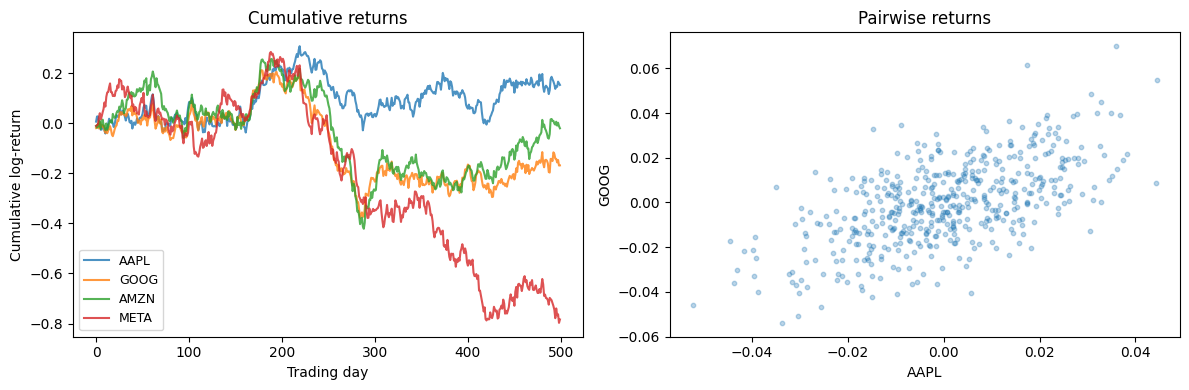

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Time series
for i, name in enumerate(stock_names):
    axes[0].plot(np.cumsum(returns[:, i]), label=name, alpha=0.8)
axes[0].set(xlabel="Trading day", ylabel="Cumulative log-return", title="Cumulative returns")
axes[0].legend(fontsize=9)

# Pairwise scatter
axes[1].scatter(returns[:, 0], returns[:, 1], alpha=0.3, s=10)
axes[1].set(xlabel=stock_names[0], ylabel=stock_names[1], title="Pairwise returns")
fig.tight_layout()
plt.show()

## Total Correlation

Total Correlation measures the overall multivariate dependence among
all stocks simultaneously: $\text{TC}(X) = \sum_i H(X_i) - H(X)$.

In [4]:
tc = total_correlation_rbig(returns)
print(f"Total Correlation: {tc:.4f} nats")

Total Correlation: 0.6994 nats


## Pairwise Mutual Information

We estimate MI between each pair of stocks. Higher MI indicates
stronger statistical dependence (linear or nonlinear).

In [5]:
n_pairs = n_stocks * (n_stocks - 1) // 2
mi_matrix = np.zeros((n_stocks, n_stocks))
icc_matrix = np.zeros((n_stocks, n_stocks))

pair_idx = 0
for i in range(n_stocks):
    for j in range(i + 1, n_stocks):
        xi = returns[:, i : i + 1]
        xj = returns[:, j : j + 1]

        model_i = AnnealedRBIG(n_layers=50, rotation="pca", random_state=42)
        model_j = AnnealedRBIG(n_layers=50, rotation="pca", random_state=42)
        model_ij = AnnealedRBIG(n_layers=50, rotation="pca", random_state=42)

        model_i.fit(xi)
        model_j.fit(xj)
        model_ij.fit(np.hstack([xi, xj]))

        mi_val = mutual_information_rbig(model_i, model_j, model_ij)
        icc_val = np.sqrt(1 - np.exp(-2 * mi_val))

        mi_matrix[i, j] = mi_matrix[j, i] = mi_val
        icc_matrix[i, j] = icc_matrix[j, i] = icc_val

        print(f"  {stock_names[i]:4s} vs {stock_names[j]:4s}: MI = {mi_val:.4f} nats, ICC = {icc_val:.4f}")

  AAPL vs GOOG: MI = 18.7229 nats, ICC = 1.0000


  AAPL vs AMZN: MI = 13.7384 nats, ICC = 1.0000


  AAPL vs META: MI = 33.7068 nats, ICC = 1.0000


  GOOG vs AMZN: MI = 30.9380 nats, ICC = 1.0000


  GOOG vs META: MI = 28.5465 nats, ICC = 1.0000


  AMZN vs META: MI = 31.1174 nats, ICC = 1.0000


### MI heatmap

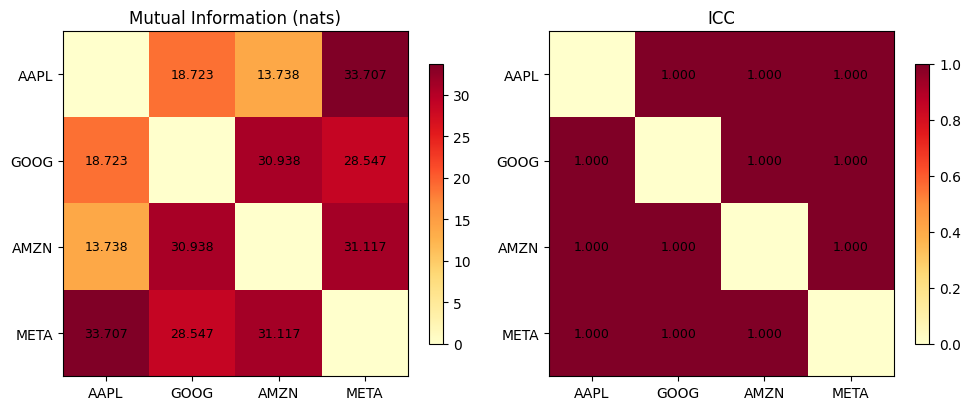

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, matrix, title in zip(axes, [mi_matrix, icc_matrix], ["Mutual Information (nats)", "ICC"]):
    im = ax.imshow(matrix, cmap="YlOrRd", vmin=0)
    ax.set_xticks(range(n_stocks))
    ax.set_yticks(range(n_stocks))
    ax.set_xticklabels(stock_names)
    ax.set_yticklabels(stock_names)
    ax.set_title(title)
    # Annotate cells
    for ii in range(n_stocks):
        for jj in range(n_stocks):
            if ii != jj:
                ax.text(jj, ii, f"{matrix[ii, jj]:.3f}", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.8)

fig.tight_layout()
plt.show()

## Group dependence: one stock vs multiple

MI can also measure dependence between a single stock and a **group**
of other stocks, capturing collective information.

In [7]:
# AAPL vs {GOOG, AMZN}
target = returns[:, 0:1]  # AAPL
group = returns[:, 1:3]   # GOOG + AMZN

model_t = AnnealedRBIG(n_layers=50, rotation="pca", random_state=42)
model_g = AnnealedRBIG(n_layers=50, rotation="pca", random_state=42)
model_tg = AnnealedRBIG(n_layers=50, rotation="pca", random_state=42)

model_t.fit(target)
model_g.fit(group)
model_tg.fit(np.hstack([target, group]))

mi_group = mutual_information_rbig(model_t, model_g, model_tg)
icc_group = np.sqrt(1 - np.exp(-2 * mi_group))

print(f"MI(AAPL ; GOOG+AMZN) = {mi_group:.4f} nats, ICC = {icc_group:.4f}")

MI(AAPL ; GOOG+AMZN) = 53.5231 nats, ICC = 1.0000


## Summary

- **Total Correlation** captures the overall multivariate dependence
  among all stocks — higher TC means more shared information.
- **Pairwise MI** reveals which stock pairs are most dependent,
  including nonlinear relationships that Pearson correlation would miss.
- **Group MI** shows that dependence on multiple stocks exceeds pairwise
  MI, reflecting collective information.
- **ICC** normalizes MI to a [0, 1] scale for easy comparison.